In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# Load data
lsoas = pd.read_csv('data/test_lsoas.csv')
imd_full = pd.read_csv('data/govuk2.csv')

score_cols = [c for c in imd_full.columns if 'Score' in c]
lsoa_col = imd_full.columns[0]
imd_features = imd_full[[lsoa_col] + score_cols].copy()
imd_features.columns = ['LSOA11CD'] + [f'score_{i}' for i in range(len(score_cols))]
lsoas_merged = lsoas.merge(imd_features, on='LSOA11CD', how='inner')
score_feature_cols = [c for c in lsoas_merged.columns if c.startswith('score_')]

print(f'LSOAs: {len(lsoas_merged)}')

Device: cpu
LSOAs: 2000


In [3]:
# ── Load model bundle ─────────────────────────────────────────────────────────
with open('models/final_spatial_bundle.pkl', 'rb') as f:
    bundle = pickle.load(f)

img_scaler = bundle['img_scaler']
pca        = bundle['pca']
tab_scaler = bundle['tab_scaler']
ridge      = bundle['ridge']
y_mean     = bundle['y_mean']
y_std      = bundle['y_std']

print('Model bundle loaded')
print(f'Ridge alpha: {ridge.alpha_:.4f}')

Model bundle loaded
Ridge alpha: 0.0100


In [4]:
# ── Extract embeddings for all LSOAs ──────────────────────────────────────────
class ImageListDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.paths[idx]).convert('RGB'))

def extract_embeddings(model, paths, transform, batch_size=32, desc=''):
    loader = DataLoader(ImageListDataset(paths, transform),
                        batch_size=batch_size, shuffle=False, num_workers=0)
    all_embs = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            emb = model(batch.to(device)).squeeze(-1).squeeze(-1)
            all_embs.append(emb.cpu().numpy())
    return np.vstack(all_embs)

transform = transforms.Compose([
    transforms.Resize(256), transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

print('Loading ResNet-50...')
resnet = models.resnet50(weights='IMAGENET1K_V2')
sv_backbone = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()
for p in sv_backbone.parameters(): p.requires_grad = False

print('Loading EfficientNet-B2...')
effnet = models.efficientnet_b2(weights='IMAGENET1K_V1')
aerial_backbone = nn.Sequential(effnet.features, effnet.avgpool).to(device).eval()
for p in aerial_backbone.parameters(): p.requires_grad = False

print('Backbones ready')

Loading ResNet-50...
Loading EfficientNet-B2...
Backbones ready


In [5]:
# Build image records
street_dir  = 'data/images/'
aerial_dir  = 'data/aerial_images/'
valid_lsoas = set(lsoas_merged['LSOA11CD'].values)

sv_records = []
for fname in os.listdir(street_dir):
    if not fname.endswith('.jpg') or fname == 'test_image.jpg': continue
    lsoa_code = fname.rsplit('_', 1)[0]
    if lsoa_code in valid_lsoas:
        sv_records.append({'path': os.path.join(street_dir, fname), 'lsoa': lsoa_code})
sv_df = pd.DataFrame(sv_records)

aerial_records = []
for fname in os.listdir(aerial_dir):
    if not fname.endswith('.jpg') or fname == 'test_aerial.jpg': continue
    lsoa_code = fname.replace('.jpg', '')
    if lsoa_code in valid_lsoas:
        aerial_records.append({'path': os.path.join(aerial_dir, fname), 'lsoa': lsoa_code})
aerial_df = pd.DataFrame(aerial_records)

print(f'Street view: {len(sv_df)} images | Aerial: {len(aerial_df)} images')

# Extract
print('Extracting street view embeddings...')
sv_embs = extract_embeddings(sv_backbone, sv_df['path'].tolist(), transform)
sv_df['emb_idx'] = range(len(sv_df))
sv_lsoa_embs = {lsoa: sv_embs[grp['emb_idx'].values].mean(axis=0)
                for lsoa, grp in sv_df.groupby('lsoa')}

print('Extracting aerial embeddings...')
aerial_embs = extract_embeddings(aerial_backbone, aerial_df['path'].tolist(), transform)
aerial_lsoa_embs = {row['lsoa']: aerial_embs[i] for i, row in aerial_df.iterrows()}

print('Done')

Street view: 6924 images | Aerial: 2000 images
Extracting street view embeddings...
Extracting aerial embeddings...
Done


In [6]:
# ── Generate predictions for all LSOAs ───────────────────────────────────────
common_lsoas = sorted(
    set(sv_lsoa_embs.keys()) &
    set(aerial_lsoa_embs.keys()) &
    valid_lsoas
)
print(f'LSOAs with all modalities: {len(common_lsoas)}')

X_img = np.array([np.concatenate([sv_lsoa_embs[l], aerial_lsoa_embs[l]])
                  for l in common_lsoas])
X_tab = np.array([lsoas_merged[lsoas_merged['LSOA11CD']==l][score_feature_cols].values[0].astype(float)
                  for l in common_lsoas])
y_true = np.array([float(lsoas_merged[lsoas_merged['LSOA11CD']==l]['IMD19'].values[0])
                   for l in common_lsoas])
lats  = np.array([float(lsoas_merged[lsoas_merged['LSOA11CD']==l]['lat'].values[0])
                  for l in common_lsoas])
lons  = np.array([float(lsoas_merged[lsoas_merged['LSOA11CD']==l]['lon'].values[0])
                  for l in common_lsoas])

# Predict — images only
Xi_s   = img_scaler.transform(X_img)
Xi_pca = pca.transform(Xi_s)
Xt_s   = tab_scaler.transform(X_tab)
X_fused = np.hstack([Xi_pca, Xt_s])

y_pred_norm  = ridge.predict(X_fused)
y_pred_fused = y_pred_norm * y_std + y_mean

# Images only prediction (zero out tabular weights)
n_pca = Xi_pca.shape[1]
ridge_img_only = ridge.coef_[:n_pca]
y_pred_img_norm = Xi_pca @ ridge_img_only + ridge.intercept_
y_pred_img = y_pred_img_norm * y_std + y_mean

errors = y_pred_img - y_true

print(f'Predictions ready for {len(common_lsoas)} LSOAs')

LSOAs with all modalities: 1731
Predictions ready for 1731 LSOAs


In [1]:
# ── Error Analysis ────────────────────────────────────────────────────────────
from sklearn.metrics import r2_score

results_df = pd.DataFrame({
    'LSOA11CD': common_lsoas,
    'true_imd': y_true,
    'pred_imd': y_pred_img,
    'error': errors,
    'abs_error': np.abs(errors),
    'lat': lats,
    'lon': lons
})

# NOTE: This R² is not the headline result. This uses images-only coefficients
# extracted from a fused model (images + tabular) and is not valid as a
# standalone images-only evaluation. The correct images-only R² = 0.2682
# comes from notebook3_main where a separate images-only model was trained
# and evaluated under spatial CV.

print(f'Overall R² (images only): {r2_score(y_true, y_pred_img):.4f}')
print(f'Mean absolute error: {results_df["abs_error"].mean():.0f} IMD ranks')
print(f'Median absolute error: {results_df["abs_error"].median():.0f} IMD ranks')

print('\n--- 10 Most Over-predicted (model thinks more deprived than reality) ---')
print(results_df.nlargest(10, 'error')[['LSOA11CD', 'true_imd', 'pred_imd', 'error']].to_string())

print('\n--- 10 Most Under-predicted (model thinks less deprived than reality) ---')
print(results_df.nsmallest(10, 'error')[['LSOA11CD', 'true_imd', 'pred_imd', 'error']].to_string())

# Error by IMD decile
results_df['decile'] = pd.qcut(results_df['true_imd'], 10, labels=False) + 1
decile_errors = results_df.groupby('decile')['abs_error'].mean()

fig, ax = plt.subplots(figsize=(10, 4))
decile_errors.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_xlabel('IMD Decile (1=most deprived, 10=least deprived)')
ax.set_ylabel('Mean Absolute Error')
ax.set_title('Prediction Error by Deprivation Decile')
ax.set_xticklabels([f'D{i}' for i in range(1,11)], rotation=0)
plt.tight_layout()
plt.savefig('outputs/error_by_decile.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nError by decile:')
print(decile_errors.to_string())

NameError: name 'pd' is not defined

In [8]:
# ── Summary statistics table ──────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('='*50)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('='*50)
print(f'Dataset: {len(common_lsoas)} London LSOAs')
print(f'Evaluation: Spatial CV (borough holdout)')
print()
print(f'Images only R²:    0.2682')
print(f'Tabular only R²:   0.9759')
print(f'Fused R²:          0.9755')
print()
print(f'Images only MAE:   {mean_absolute_error(y_true, y_pred_img):.0f} IMD ranks')
print(f'Images only RMSE:  {np.sqrt(mean_squared_error(y_true, y_pred_img)):.0f} IMD ranks')
print('='*50)

FINAL MODEL PERFORMANCE SUMMARY
Dataset: 1731 London LSOAs
Evaluation: Spatial CV (borough holdout)

Images only R²:    0.2682
Tabular only R²:   0.9759
Fused R²:          0.9755

Images only MAE:   7019 IMD ranks
Images only RMSE:  8173 IMD ranks


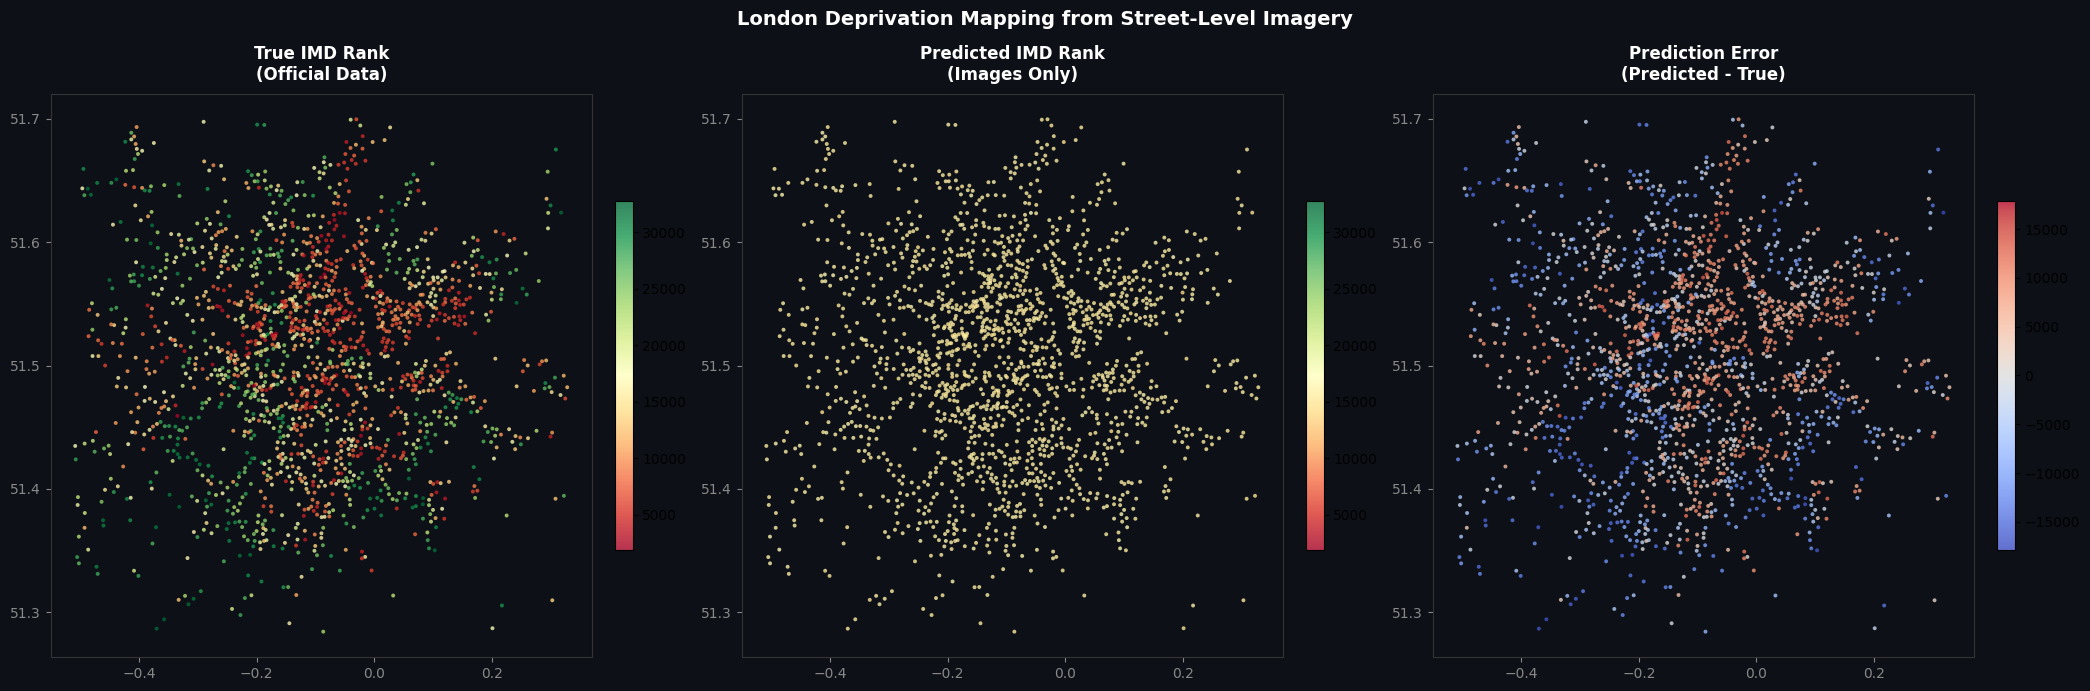

Saved!


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(21, 7))
fig.patch.set_facecolor('#0d1117')
cmap = plt.cm.RdYlGn
vmin, vmax = y_true.min(), y_true.max()
err_max = np.abs(errors).max()

titles = ['True IMD Rank\n(Official Data)', 'Predicted IMD Rank\n(Images Only)', 'Prediction Error\n(Predicted - True)']
cmaps  = [cmap, cmap, 'coolwarm']
vmins  = [vmin, vmin, -err_max]
vmaxs  = [vmax, vmax,  err_max]
vals   = [y_true, y_pred_img, errors]

for ax, v, t, c, vn, vx in zip(axes, vals, titles, cmaps, vmins, vmaxs):
    ax.set_facecolor('#0d1117')
    sc = ax.scatter(lons, lats, c=v, cmap=c, vmin=vn, vmax=vx, s=8, alpha=0.8, linewidths=0)
    ax.set_title(t, color='white', fontsize=12, fontweight='bold', pad=10)
    ax.tick_params(colors='#888888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333333')
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04)

plt.suptitle('London Deprivation Mapping from Street-Level Imagery',
             color='white', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/london_deprivation_map.png', dpi=200,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved!')